# NYISO Solar Forecasting: Baseline Models

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [8]:
# repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"
repo_root = Path(r"C:\Users\sumai\Documents\ML_NYISOSolarForecasting")

data_root = repo_root / "data"
processed_dir = data_root / "processed"

model_ready_in = processed_dir / "04_system_model_ready_data.csv"

split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")
validation_start = pd.Timestamp("2024-01-01 00:00:00+00:00")

## Load Dataset

In [9]:
df_model = pd.read_csv(model_ready_in, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model["time_stamp"] = pd.to_datetime(df_model["time_stamp"], utc=True, errors="coerce")
df_model["time_local"] = df_model["time_stamp"].dt.tz_convert("America/New_York")

print("Shape:", df_model.shape)
print("Time Range:", df_model["time_stamp"].min(), "to", df_model["time_stamp"].max())
print("Columns:")
print(". . .")
print(df_model.columns.tolist())

Shape: (41455, 30)
Time Range: 2020-11-17 05:00:00+00:00 to 2025-09-19 03:00:00+00:00
Columns:
. . .
['time_stamp', 'time_local', 'zone_name', 'dataset_split', 'actual_mw', 'forecast_mw', 'forecast_error_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Main Features and Time Context

In [10]:
target = "forecast_error_mw"

required_cols = [
    "time_stamp",
    "time_local",
    "zone_name",
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
]

missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing Necessary Columns in Dataset: {missing_required}")

df_model["hour_local"] = df_model["time_local"].dt.hour
df_model["month_local"] = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"] = (df_model["shortwave_radiation"] > 0).astype(int)

feature_cols = [c for c in df_model.columns if c not in required_cols + [
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
]]

print("\nTarget:", target)
print("Number of Features:", len(feature_cols))
print("Feature Columns:")
print(". . .")
print(feature_cols)


Target: forecast_error_mw
Number of Features: 23
Feature Columns:
. . .
['temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Train, Validation, and Test Splits

In [11]:
train_end = df_model.loc[df_model["dataset_split"].eq("train"), "time_stamp"].max()
test_start = df_model.loc[df_model["dataset_split"].eq("test"), "time_stamp"].min()

print("Latest train Timestamp:", train_end)
print("Earliest Test Timestamp:", test_start)

Latest train Timestamp: 2024-06-30 23:00:00+00:00
Earliest Test Timestamp: 2024-07-01 00:00:00+00:00


In [12]:
X = df_model[feature_cols].copy()
y = df_model[target].copy()

train_mask = (
    df_model["dataset_split"].eq("train")
    & y.notna()
)

test_mask = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

subtrain_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].lt(validation_start)
    & df_model[target].notna()
)

valid_mask = (
    df_model["dataset_split"].eq("train")
    & df_model["time_stamp"].ge(validation_start)
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

train_df = df_model.loc[train_mask].copy()
test_df = df_model.loc[test_mask].copy()
subtrain_df = df_model.loc[subtrain_mask].copy()
valid_df = df_model.loc[valid_mask].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
X_subtrain = subtrain_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()
y_subtrain = subtrain_df[target].copy()
y_valid = valid_df[target].copy()

baseline_actual_test = test_df["actual_mw"].copy()
baseline_forecast_test = test_df["forecast_mw"].copy()

baseline_actual_valid = valid_df["actual_mw"].copy()
baseline_forecast_valid = valid_df["forecast_mw"].copy()

daylight_test_mask = test_df["is_daylight"] == 1
daylight_valid_mask = valid_df["is_daylight"] == 1

In [13]:
print("\nTarget:", target)
print("Number of Features:", len(feature_cols))
print("Feature Columns:")
print(feature_cols)

print("\nTrain/Test/Validation Shapes")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_subtrain:", X_subtrain.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("y_subtrain:", y_subtrain.shape)
print("y_valid:", y_valid.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_subtrain.shape[0] == y_subtrain.shape[0]
assert X_valid.shape[0] == y_valid.shape[0]


Target: forecast_error_mw
Number of Features: 23
Feature Columns:
['temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']

Train/Test/Validation Shapes
X_train: (30921, 23)
X_test: (10534, 23)
X_subtrain: (26630, 23)
X_valid: (4291, 23)
y_train: (30921,)
y_test: (10534,)
y_subtrain: (26630,)
y_valid: (4291,)


## Feature Diagnostics for Training

In [14]:
feature_diagnostics = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(X_train[c].dtype) for c in feature_cols],
    "missing_train": [int(X_train[c].isna().sum()) for c in feature_cols],
    "missing_train_pct": [100 * X_train[c].isna().mean() for c in feature_cols],
    "nunique_train": [X_train[c].nunique(dropna=True) for c in feature_cols],
    "std_train": [X_train[c].std(skipna=True) for c in feature_cols],
}).sort_values(
    ["missing_train_pct", "nunique_train", "feature"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\Feature Diagnostics")
print(". . .")
print(feature_diagnostics)

\Feature Diagnostics
. . .
                   feature    dtype  missing_train  missing_train_pct  nunique_train    std_train
0    forecast_roll_mean_24  float64             11           0.035575          17339   299.234017
1          forecast_diff_1  float64             11           0.035575          17604   225.694664
2     forecast_roll_mean_3  float64             11           0.035575          19760   725.500029
3       shortwave_ramp_abs  float64              1           0.003234            402    67.637973
4         shortwave_diff_1  float64              1           0.003234            712    83.633426
5    shortwave_roll_mean_3  float64              1           0.003234           2638   225.184667
6   shortwave_roll_mean_24  float64              1           0.003234           6791    90.812154
7                is_midday    int64              0           0.000000              2     0.406219
8          is_morning_ramp    int64              0           0.000000              2     0.

In [15]:
corr_input = X_train.copy()
corr_input = corr_input.fillna(corr_input.median(numeric_only=True))

corr_matrix = corr_input.corr(numeric_only=True).abs()

high_corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val >= 0.98:
            high_corr_pairs.append((cols[i], cols[j], corr_val))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "abs_corr"]
).sort_values("abs_corr", ascending=False)

print("\nHigh-Correlation Pairs (|corr| >= 0.98)")
print(high_corr_pairs_df if len(high_corr_pairs_df) > 0 else "nothing found")


High-Correlation Pairs (|corr| >= 0.98)
nothing found


## Evaluation Metrics

In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_forecasts(actual, forecast):
    return {
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": rmse(actual, forecast),
    }


def evaluate_daylight_forecasts(actual, forecast, daylight_mask):
    return {
        "Daylight_MAE": mean_absolute_error(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
        "Daylight_RMSE": rmse(actual.loc[daylight_mask], forecast.loc[daylight_mask]),
    }


def summarize_model(name, actual, forecast, daylight_mask):
    out = {"Model": name}
    out.update(evaluate_forecasts(actual, forecast))
    out.update(evaluate_daylight_forecasts(actual, forecast, daylight_mask))
    return out

def apply_physical_bounds(forecast_series):
    return pd.Series(forecast_series, index=forecast_series.index).clip(lower=0.0)

def build_prediction_frame(model_name, eval_df, corrected_forecast):
    pred_df = eval_df[[
        "time_stamp",
        "time_local",
        "actual_mw",
        "forecast_mw",
        "hour_local",
        "month_local",
        "is_daylight",
    ]].copy()

    pred_df["model_name"] = model_name
    pred_df["corrected_forecast_mw"] = corrected_forecast
    pred_df["baseline_error_mw"] = pred_df["actual_mw"] - pred_df["forecast_mw"]
    pred_df["model_error_mw"] = pred_df["actual_mw"] - pred_df["corrected_forecast_mw"]
    pred_df["baseline_abs_error_mw"] = pred_df["baseline_error_mw"].abs()
    pred_df["model_abs_error_mw"] = pred_df["model_error_mw"].abs()

    return pred_df


def fit_hourly_residual_climatology(fit_df):
    return fit_df.groupby("hour_local")[target].mean()


def predict_hourly_residual_climatology(eval_df, hourly_map, global_fallback):
    pred_residual = eval_df["hour_local"].map(hourly_map).fillna(global_fallback)
    return eval_df["forecast_mw"] + pred_residual


def fit_month_hour_residual_climatology(fit_df):
    month_hour_map = fit_df.groupby(["month_local", "hour_local"])[target].mean()
    hour_map = fit_df.groupby("hour_local")[target].mean()
    global_mean = fit_df[target].mean()
    return month_hour_map, hour_map, global_mean


def predict_month_hour_residual_climatology(eval_df, month_hour_map, hour_map, global_mean):
    pred_residual = []
    for month_val, hour_val in zip(eval_df["month_local"], eval_df["hour_local"]):
        if (month_val, hour_val) in month_hour_map.index:
            pred_residual.append(month_hour_map.loc[(month_val, hour_val)])
        elif hour_val in hour_map.index:
            pred_residual.append(hour_map.loc[hour_val])
        else:
            pred_residual.append(global_mean)

    pred_residual = pd.Series(pred_residual, index=eval_df.index)
    return eval_df["forecast_mw"] + pred_residual


def build_ridge_pipeline(feature_names, alpha=1.0):
    ridge_preprocess = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                feature_names,
            )
        ],
        remainder="drop",
    )

    ridge_model = Pipeline(
        steps=[
            ("prep", ridge_preprocess),
            ("model", Ridge(alpha=alpha)),
        ]
    )
    return ridge_model

## Baseline Model Definitions

In [17]:
nyiso_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"].copy())
nyiso_test_forecast = apply_physical_bounds(test_df["forecast_mw"].copy())

mean_residual_subtrain = subtrain_df[target].mean()
mean_residual_train = train_df[target].mean()

mean_resid_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + mean_residual_subtrain)
mean_resid_test_forecast = apply_physical_bounds(test_df["forecast_mw"] + mean_residual_train)

hourly_map_subtrain = fit_hourly_residual_climatology(subtrain_df)
hourly_map_train = fit_hourly_residual_climatology(train_df)

global_mean_subtrain = subtrain_df[target].mean()
global_mean_train = train_df[target].mean()

hourly_valid_forecast = apply_physical_bounds(
    predict_hourly_residual_climatology(valid_df, hourly_map_subtrain, global_mean_subtrain)
)
hourly_test_forecast = apply_physical_bounds(
    predict_hourly_residual_climatology(test_df, hourly_map_train, global_mean_train)
)

month_hour_map_subtrain, hour_map_subtrain, global_mean_subtrain = fit_month_hour_residual_climatology(subtrain_df)
month_hour_map_train, hour_map_train, global_mean_train = fit_month_hour_residual_climatology(train_df)

month_hour_valid_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(
        valid_df,
        month_hour_map_subtrain,
        hour_map_subtrain,
        global_mean_subtrain,
    )
)

month_hour_test_forecast = apply_physical_bounds(
    predict_month_hour_residual_climatology(
        test_df,
        month_hour_map_train,
        hour_map_train,
        global_mean_train,
    )
)

In [18]:
ridge_model_valid = build_ridge_pipeline(feature_cols, alpha=1.0)
ridge_model_valid.fit(X_subtrain, y_subtrain)

ridge_valid_residual_pred = ridge_model_valid.predict(X_valid)
ridge_valid_forecast = apply_physical_bounds(valid_df["forecast_mw"] + ridge_valid_residual_pred)

ridge_model_test = build_ridge_pipeline(feature_cols, alpha=1.0)
ridge_model_test.fit(X_train, y_train)

ridge_test_residual_pred = ridge_model_test.predict(X_test)
ridge_test_forecast = apply_physical_bounds(test_df["forecast_mw"] + ridge_test_residual_pred)

## Validation Results

In [19]:
validation_results = pd.DataFrame([
    summarize_model("NYISO Baseline", baseline_actual_valid, nyiso_valid_forecast, daylight_valid_mask),
    summarize_model("Mean Residual Correction", baseline_actual_valid, mean_resid_valid_forecast, daylight_valid_mask),
    summarize_model("Hourly Residual Climatology", baseline_actual_valid, hourly_valid_forecast, daylight_valid_mask),
    summarize_model("Month-Hour Residual Climatology", baseline_actual_valid, month_hour_valid_forecast, daylight_valid_mask),
    summarize_model("Ridge Residual Model", baseline_actual_valid, ridge_valid_forecast, daylight_valid_mask),
])

baseline_valid_mae = validation_results.loc[
    validation_results["Model"] == "NYISO Baseline", "MAE"
].iloc[0]
baseline_valid_rmse = validation_results.loc[
    validation_results["Model"] == "NYISO Baseline", "RMSE"
].iloc[0]
baseline_valid_daylight_mae = validation_results.loc[
    validation_results["Model"] == "NYISO Baseline", "Daylight_MAE"
].iloc[0]
baseline_valid_daylight_rmse = validation_results.loc[
    validation_results["Model"] == "NYISO Baseline", "Daylight_RMSE"
].iloc[0]

validation_results["MAE_Improvement_vs_NYISO"] = baseline_valid_mae - validation_results["MAE"]
validation_results["RMSE_Improvement_vs_NYISO"] = baseline_valid_rmse - validation_results["RMSE"]
validation_results["Daylight_MAE_Improvement_vs_NYISO"] = baseline_valid_daylight_mae - validation_results["Daylight_MAE"]
validation_results["Daylight_RMSE_Improvement_vs_NYISO"] = baseline_valid_daylight_rmse - validation_results["Daylight_RMSE"]

validation_results = validation_results.sort_values(
    ["Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\nValidation Results")
print(validation_results)


Validation Results
                             Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0  Month-Hour Residual Climatology  103.167315  205.765172    186.176641     277.875838                  0.794645   
1                   NYISO Baseline  103.961960  209.115931    187.542605     282.395250                  0.000000   
2         Mean Residual Correction  103.978546  209.138895    187.570846     282.426010                 -0.016587   
3             Ridge Residual Model  110.050878  202.093937    188.094941     272.405759                 -6.088918   
4      Hourly Residual Climatology  104.563867  208.096354    188.352782     280.975543                 -0.601907   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  
0                   3.350759                           1.365964                            4.519411  
1                   0.000000                           0.000000          

In [20]:
best_model_name = validation_results.iloc[0]["Model"]
print("\nBest Model Chosen From Validation Set:", best_model_name)


Best Model Chosen From Validation Set: Month-Hour Residual Climatology


## Test Results

In [21]:
test_results = pd.DataFrame([
    summarize_model("NYISO Baseline", baseline_actual_test, nyiso_test_forecast, daylight_test_mask),
    summarize_model("Mean Residual Correction", baseline_actual_test, mean_resid_test_forecast, daylight_test_mask),
    summarize_model("Hourly Residual Climatology", baseline_actual_test, hourly_test_forecast, daylight_test_mask),
    summarize_model("Month-Hour Residual Climatology", baseline_actual_test, month_hour_test_forecast, daylight_test_mask),
    summarize_model("Ridge Residual Model", baseline_actual_test, ridge_test_forecast, daylight_test_mask),
])

baseline_test_mae = test_results.loc[
    test_results["Model"] == "NYISO Baseline", "MAE"
].iloc[0]
baseline_test_rmse = test_results.loc[
    test_results["Model"] == "NYISO Baseline", "RMSE"
].iloc[0]
baseline_test_daylight_mae = test_results.loc[
    test_results["Model"] == "NYISO Baseline", "Daylight_MAE"
].iloc[0]
baseline_test_daylight_rmse = test_results.loc[
    test_results["Model"] == "NYISO Baseline", "Daylight_RMSE"
].iloc[0]

test_results["MAE_Improvement_vs_NYISO"] = baseline_test_mae - test_results["MAE"]
test_results["RMSE_Improvement_vs_NYISO"] = baseline_test_rmse - test_results["RMSE"]
test_results["Daylight_MAE_Improvement_vs_NYISO"] = baseline_test_daylight_mae - test_results["Daylight_MAE"]
test_results["Daylight_RMSE_Improvement_vs_NYISO"] = baseline_test_daylight_rmse - test_results["Daylight_RMSE"]

test_results = test_results.sort_values(
    ["Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\nTest Results")
print(test_results)


Test Results
                             Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0             Ridge Residual Model  102.330966  193.740900    175.588344     260.425652                  4.571100   
1  Month-Hour Residual Climatology  101.068122  200.765909    181.321095     270.443988                  5.833944   
2      Hourly Residual Climatology  106.222922  206.657158    189.653890     278.170350                  0.679145   
3                   NYISO Baseline  106.902067  207.701248    190.600140     279.509913                  0.000000   
4         Mean Residual Correction  108.101644  207.868022    191.135227     279.709973                 -1.199577   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  
0                  13.960348                          15.011796                           19.084260  
1                   6.935339                           9.279045                

## Validation-Selected Model Diagnostics

In [22]:
prediction_frames = {
    "NYISO Baseline": build_prediction_frame("NYISO Baseline", test_df, nyiso_test_forecast),
    "Mean Residual Correction": build_prediction_frame("Mean Residual Correction", test_df, mean_resid_test_forecast),
    "Hourly Residual Climatology": build_prediction_frame("Hourly Residual Climatology", test_df, hourly_test_forecast),
    "Month-Hour Residual Climatology": build_prediction_frame("Month-Hour Residual Climatology", test_df, month_hour_test_forecast),
    "Ridge Residual Model": build_prediction_frame("Ridge Residual Model", test_df, ridge_test_forecast),
}

best_pred_df = prediction_frames[best_model_name].copy()

print("\nValidation-Selected Model Evaluated On Test Set:", best_model_name)


Validation-Selected Model Evaluated On Test Set: Month-Hour Residual Climatology


In [23]:
diag_day = best_pred_df.loc[best_pred_df["is_daylight"] == 1].copy()

hourly_day = (
    diag_day.groupby("hour_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

monthly_all = (
    best_pred_df.groupby("month_local", as_index=False)[
        ["baseline_abs_error_mw", "model_abs_error_mw"]
    ].mean()
)

recent_plot = best_pred_df.tail(min(24 * 21, len(best_pred_df))).copy()

In [59]:
residual_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
    ],
    "value": [
        best_pred_df["baseline_error_mw"].mean(),
        best_pred_df["baseline_error_mw"].std(),
        best_pred_df["model_error_mw"].mean(),
        best_pred_df["model_error_mw"].std(),
        best_pred_df["baseline_abs_error_mw"].mean(),
        best_pred_df["model_abs_error_mw"].mean(),
    ],
})

print("\nResidual Summary")
print(residual_summary)


Residual Summary
                    metric       value
0      baseline_error_mean  -14.917052
1       baseline_error_std  207.174720
2         model_error_mean  -12.477986
3          model_error_std  200.387280
4  baseline_abs_error_mean  106.902067
5     model_abs_error_mean  101.068122


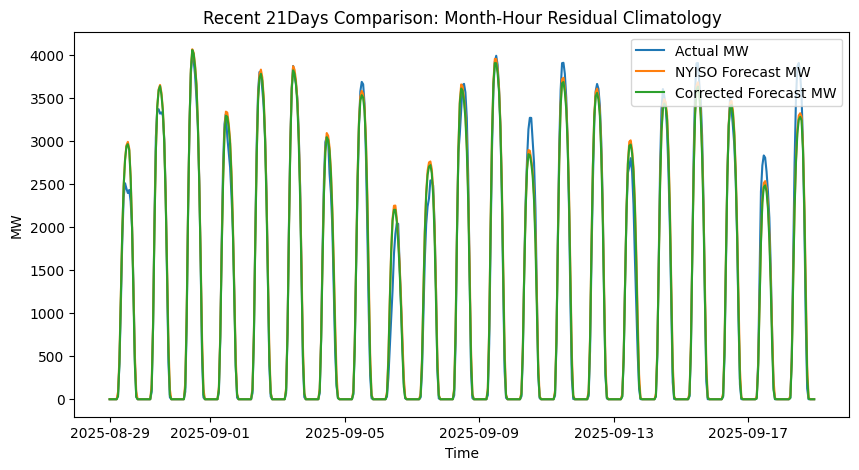

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(recent_plot["time_local"], recent_plot["actual_mw"], label="Actual MW")
plt.plot(recent_plot["time_local"], recent_plot["forecast_mw"], label="NYISO Forecast MW")
plt.plot(recent_plot["time_local"], recent_plot["corrected_forecast_mw"], label="Corrected Forecast MW")
plt.title(f"Recent 21Days Comparison: {best_model_name}")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()
plt.show()

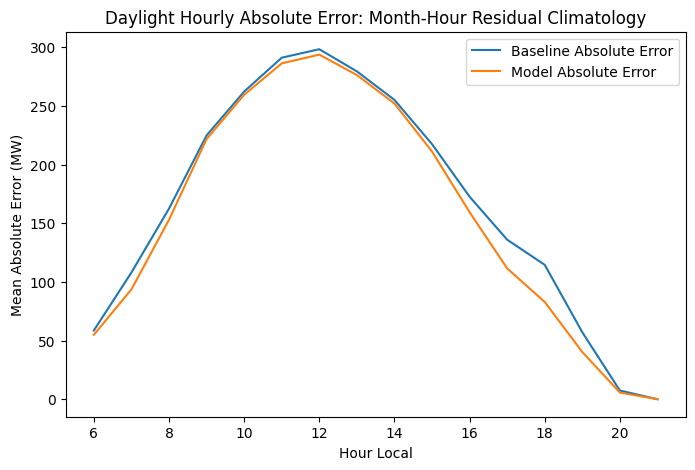

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(hourly_day["hour_local"], hourly_day["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(hourly_day["hour_local"], hourly_day["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Daylight Hourly Absolute Error: {best_model_name}")
plt.xlabel("Hour Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

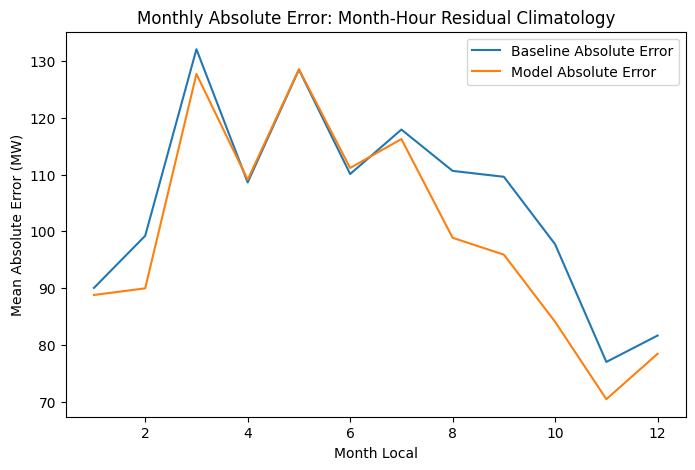

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_all["month_local"], monthly_all["baseline_abs_error_mw"], label="Baseline Absolute Error")
plt.plot(monthly_all["month_local"], monthly_all["model_abs_error_mw"], label="Model Absolute Error")
plt.title(f"Monthly Absolute Error: {best_model_name}")
plt.xlabel("Month Local")
plt.ylabel("Mean Absolute Error (MW)")
plt.legend()
plt.show()

## Findings for the Baseline Section

## Conclusion and Next Steps
x